   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


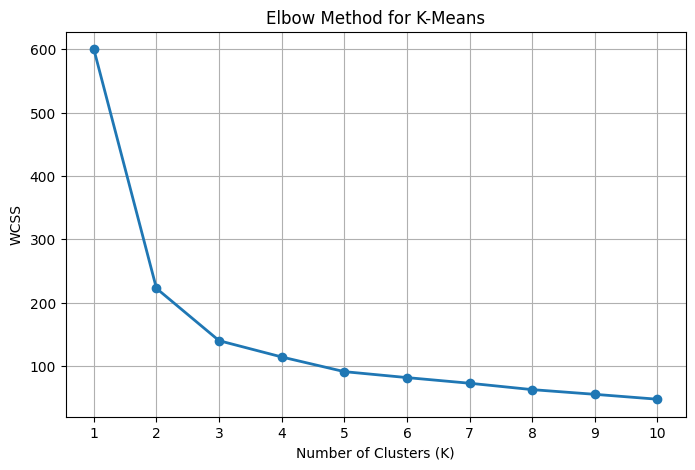

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

iris = load_iris()


df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)


print(df.head())


X = df.copy()

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)



wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(x_scaled)

    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o',
    linewidth=2
)

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1, 11))
plt.grid(True)

plt.show()



In [39]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(x_scaled)

df["cluster"] = clusters


In [42]:


score = silhouette_score(x_scaled, clusters)

print("\nSilhouette Score:", score)



Silhouette Score: 0.45994823920518646


<Axes: title={'center': 'K-Means Clustering on Iris Dataset'}>

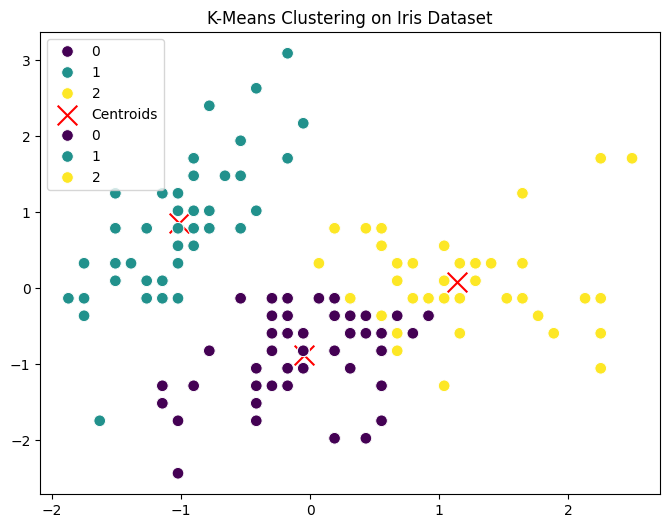

In [45]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=x_scaled[:, 0],
    y=x_scaled[:, 1],
    hue=clusters,
    palette='viridis',
    s=70
)

centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=200,
    c='red',
    marker='x',
    label='Centroids'
)

plt.title("K-Means Clustering on Iris Dataset")
sns.scatterplot(
    x=x_scaled[:, 0],
    y=x_scaled[:, 1],
    hue=clusters,
    palette='viridis',
    s=70
)



